In [131]:
import pandas as pd
import os
import glob
import numpy as np

In [2]:
import dupIO

In [28]:
b4IDs = pd.read_csv("../dupcaller-test/batch4/batch4_IDs.txt", sep="\t")
b4IDs = b4IDs.loc[b4IDs.sample_type=="sample"]
b4IDs["caste"] = "Worker"
b4IDs["age"] = [-18, -15, -15, -10, -6, -4] # based on a hatching data of 21 days for workers.

In [32]:
# ages for the batch3
age_string = """9wW2	9
0dW7	0
9wW3	9
9wW1	9
0dW9	0
5wW1	5
5wW2	5
6wW2	6
0dW8	0
0dQ6	0
nQ10	3
gQ3	2
nQ8	3
0dQ5	0
gQ8	1
gQ9	1
nQ9	3
sQ3	2"""
aged = {i.split('\t')[0]:i.split('\t')[1] for i in age_string.split('\n')}

In [5]:
# load dupcaller output - whole VCF - batch3
folder="/home/tilman/osmia_store/dupcaller-test/test-data/output/"
sample_vcfs = dupIO.load_all_dupcaller_vcfs(folder)
sample_vcfs = {key:item for key,item in sample_vcfs.items() if not sample_to_caste[key]=="beetle"}
df_long = dupIO.vcfs_to_long(sample_vcfs)


In [33]:
folder="/home/tilman/osmia_store/dupcaller-test/batch4/output"
sample_vcfs = dupIO.load_all_dupcaller_vcfs(folder)
df_long_b4 = dupIO.vcfs_to_long(sample_vcfs)


In [45]:
# get counts for dupcaller output
counts = df_long.groupby(["sample", "variant_type"]).size().reset_index(name="count")
counts['age'] = [int(aged[k['sample']]) for i,k in counts.iterrows()]
counts["caste"] = counts["sample"].str.extract(r'([A-Za-z])[^A-Za-z]*$', expand=False)
counts['abs_age'] = [k['age']*365 if k['caste']=='Q' else k['age']*7 for i,k in counts.iterrows()]

In [48]:
# get counts for dupcaller output batch 4
counts_b4 = df_long_b4.groupby(["sample", "variant_type"]).size().reset_index(name="count")
counts_b4['age'] = [b4IDs.loc[b4IDs.sample_ID==k["sample"]].age.iloc[0] for i,k in counts_b4.iterrows() ]
counts_b4['abs_age'] = [b4IDs.loc[b4IDs.sample_ID==k["sample"]].age.iloc[0] for i,k in counts_b4.iterrows() ]
counts_b4["caste"] = 'W'
#counts['abs_age'] = [k['age']*365 if k['caste']=='Q' else k['age']*7 for i,k in counts.iterrows()]

In [41]:
b4IDs.loc[b4IDs.sample_ID=="E03"].age.iloc[0]

np.int64(-18)

In [50]:
# load dupcaller output: coverage
dcstats = dupIO.load_dupcaller_stats(folder="/home/tilman/osmia_store/dupcaller-test/test-data/output/")
# df_stats is your stats-wide table (rows = metrics, columns = samples)
# value you want to exclude, e.g. "queen"
caste_to_exclude = "beetle"

dcstats_f = dcstats[[i for i in dcstats.columns if not sample_to_caste[i]=="beetle"]].copy()
dcstats_ft = dcstats_f.T

In [51]:
# load dupcaller output: coverage
dcstats_b4 = dupIO.load_dupcaller_stats(folder="/home/tilman/osmia_store/dupcaller-test/batch4/output")
# df_stats is your stats-wide table (rows = metrics, columns = samples)
# value you want to exclude, e.g. "queen"

dcstats_ft_b4 = dcstats_b4.T

In [53]:
counts = counts.merge(dcstats_ft, left_on="sample", right_index=True)
counts["burden"]=counts["count"]/counts["Effective Coverage"]

In [54]:
counts_b4 = counts_b4.merge(dcstats_ft_b4, left_on="sample", right_index=True)
counts_b4["burden"]=counts_b4["count"]/counts_b4["Effective Coverage"]

In [55]:
counts_b4

,sample,variant_type,count,age,abs_age,caste,Number of Read Families,Number of Pass-filter Reads,Number of Effective Read Families,Effective Coverage,Per Read Family Coverage,Pass-filter Duplication Rate,Efficiency,burden
0,11d1,indel,35,-10,-10,W,589368551.0,9.541345e+08,73841570.0,3.823161e+09,51.775183,0.382300,0.068588,9.154729e-09
1,11d1,snv,80,-10,-10,W,589368551.0,9.541345e+08,73841570.0,3.823161e+09,51.775183,0.382300,0.068588,2.092509e-08
2,15d1,indel,15,-6,-6,W,517935770.0,8.508448e+08,60998394.0,3.226527e+09,52.895273,0.391269,0.063170,4.648962e-09
3,15d1,snv,39,-6,-6,W,517935770.0,8.508448e+08,60998394.0,3.226527e+09,52.895273,0.391269,0.063170,1.208730e-08
4,17d1,indel,77,-4,-4,W,570160471.0,1.015542e+09,79633134.0,4.132261e+09,51.891222,0.438565,0.069669,1.863387e-08
5,17d1,snv,120,-4,-4,W,570160471.0,1.015542e+09,79633134.0,4.132261e+09,51.891222,0.438565,0.069669,2.903979e-08
6,6d1,indel,32,-15,-15,W,591046717.0,1.010014e+09,80352438.0,4.471861e+09,55.653086,0.414813,0.069645,7.155857e-09
7,6d1,snv,28,-15,-15,W,591046717.0,1.010014e+09,80352438.0,4.471861e+09,55.653086,0.414813,0.069645,6.261375e-09
8,6d2,indel,25,-15,-15,W,600780063.0,1.037768e+09,80392111.0,4.486848e+09,55.812049,0.421085,0.068688,5.571840e-09
9,6d2,snv,81,-15,-15,W,600780063.0,1.037768e+09,80392111.0,4.486848e+09,55.812049,0.421085,0.068688,1.805276e-08


In [57]:
counts_all = pd.concat([counts,counts_b4])

### Exact Poisson Confidence Interval for Mutation Rate

Let:

- $n$ = number of observed somatic variants  
- $M$ = number of callable bases (exposure)  

Estimated mutation rate:
$$
\hat{r} = \frac{n}{M}
$$

Assume:
$$
n \sim \text{Poisson}(r M)
$$

An exact $100(1-\alpha)\%$ confidence interval for the Poisson mean $\mu = r M$ is:
$$
\mu_{\text{low}} = \frac{1}{2} \chi^2_{\alpha/2,\; 2n}
$$
$$
\mu_{\text{high}} = \frac{1}{2} \chi^2_{1-\alpha/2,\; 2(n+1)}
$$

Convert to a confidence interval for the mutation rate:
$$
r_{\text{low}} = \frac{\mu_{\text{low}}}{M}, \qquad
r_{\text{high}} = \frac{\mu_{\text{high}}}{M}
$$

If reporting per megabase:
$$
r_{\text{low}}^{(\text{per Mb})} = 10^6\, r_{\text{low}}, \qquad
r_{\text{high}}^{(\text{per Mb})} = 10^6\, r_{\text{high}}
$$

**Special case: $n = 0$**
$$
\mu_{\text{low}} = 0
$$
$$
\mu_{\text{high}} = \frac{1}{2} \chi^2_{1-\alpha/2,\; 2}
$$


In [58]:
from scipy.stats import chi2

def poisson_rate_ci(n, M, alpha=0.05):
    """
    Exact Poisson confidence interval for a mutation rate r
    when the count n ~ Poisson(r * M).

    Parameters
    ----------
    n : int
        Observed number of variants.
    M : float
        Exposure, e.g. number of callable bases.
    alpha : float, optional
        1 - confidence level (default 0.05 for 95% CI).

    Returns
    -------
    r_hat : float
        Point estimate of rate per base.
    r_low : float
        Lower bound of CI per base.
    r_high : float
        Upper bound of CI per base.
    """
    # Point estimate
    r_hat = n / M

    # Lower bound for the Poisson mean
    if n > 0:
        mu_low = 0.5 * chi2.ppf(alpha / 2, 2 * n)
    else:
        mu_low = 0.0

    # Upper bound for the Poisson mean
    mu_high = 0.5 * chi2.ppf(1 - alpha / 2, 2 * (n + 1))

    # Convert means to rates
    r_low = mu_low / M
    r_high = mu_high / M

    return r_hat, r_low, r_high

In [59]:
r_low_l = []
r_high_l = []

for i,k in counts_all.iterrows():
    print(f"{k['sample']} type:{k.variant_type}")
    n=k['count']
    M=k['Effective Coverage']
    r_hat, r_low, r_high = poisson_rate_ci(n, M)
    print("Rate per base:")
    print("  r_hat =", r_hat)
    print("  CI    = [", r_low, ",", r_high, "]")
    r_low_l.append(r_low)
    r_high_l.append(r_high)

    print("\nRate per Mb:")
    print("  r_hat =", r_hat * 1e6)
    print("  CI    = [", r_low * 1e6, ",", r_high * 1e6, "]")
    print("-----------------------------------------------------")

0dQ5 type:indel
Rate per base:
  r_hat = 1.5550767431642732e-08
  CI    = [ 1.049203748400986e-08 , 2.2199687452697404e-08 ]

Rate per Mb:
  r_hat = 0.015550767431642732
  CI    = [ 0.010492037484009861 , 0.022199687452697403 ]
-----------------------------------------------------
0dQ5 type:snv
Rate per base:
  r_hat = 3.991363640788301e-08
  CI    = [ 3.14992176735194e-08 , 4.988519721112003e-08 ]

Rate per Mb:
  r_hat = 0.03991363640788301
  CI    = [ 0.0314992176735194 , 0.04988519721112003 ]
-----------------------------------------------------
0dQ6 type:indel
Rate per base:
  r_hat = 1.1116143877319577e-08
  CI    = [ 6.790029469572137e-09 , 1.7167982645157477e-08 ]

Rate per Mb:
  r_hat = 0.011116143877319577
  CI    = [ 0.006790029469572138 , 0.017167982645157478 ]
-----------------------------------------------------
0dQ6 type:snv
Rate per base:
  r_hat = 2.8346166887164923e-08
  CI    = [ 2.110558311171458e-08 , 3.726997451798194e-08 ]

Rate per Mb:
  r_hat = 0.028346166887164

In [60]:
counts_all['r_high'] = r_high_l
counts_all['r_low'] = r_low_l

In [201]:
# Collapse SNV and indel entries per sample
collapsed = counts_all.groupby("sample").agg({
    "count": "sum",            # total variants
    "Effective Coverage": "first"           # same for both entries
}).reset_index()


In [202]:
def poisson_rate_ci(n, M, alpha=0.05):
    from scipy.stats import chi2

    r_hat = n / M
    
    if n > 0:
        mu_low = 0.5 * chi2.ppf(alpha / 2, 2 * n)
    else:
        mu_low = 0.0
    
    mu_high = 0.5 * chi2.ppf(1 - alpha / 2, 2 * (n + 1))
    
    return r_hat, mu_low/M, mu_high/M


In [203]:
collapsed[["burden", "r_low", "r_high"]] = collapsed.apply(
    lambda row: poisson_rate_ci(row["count"], row["Effective Coverage"]),
    axis=1,
    result_type="expand"
)


In [204]:
collapsed = collapsed.merge(
    counts_all[["sample", "abs_age", 'caste']].drop_duplicates(),
    on="sample"
)

In [205]:
collapsed

,sample,count,Effective Coverage,burden,r_low,r_high,abs_age,caste
0,0dQ5,107,1.929165e+09,5.546440e-08,4.545442e-08,6.702305e-08,0,Q
1,0dQ6,71,1.799185e+09,3.946231e-08,3.082039e-08,4.977634e-08,0,Q
2,0dW8,117,1.746764e+09,6.698099e-08,5.539510e-08,8.027496e-08,0,W
3,0dW9,159,1.660480e+09,9.575547e-08,8.145005e-08,1.118502e-07,0,W
4,11d1,115,3.823161e+09,3.007982e-08,2.483398e-08,3.610627e-08,-10,W
5,15d1,54,3.226527e+09,1.673626e-08,1.257280e-08,2.183719e-08,-6,W
6,17d1,197,4.132261e+09,4.767366e-08,4.124852e-08,5.481594e-08,-4,W
7,5wW2,71,1.807769e+09,3.927494e-08,3.067405e-08,4.953999e-08,35,W
8,6d1,60,4.471861e+09,1.341723e-08,1.023876e-08,1.727064e-08,-15,W
9,6d2,106,4.486848e+09,2.362460e-08,1.934189e-08,2.857327e-08,-15,W


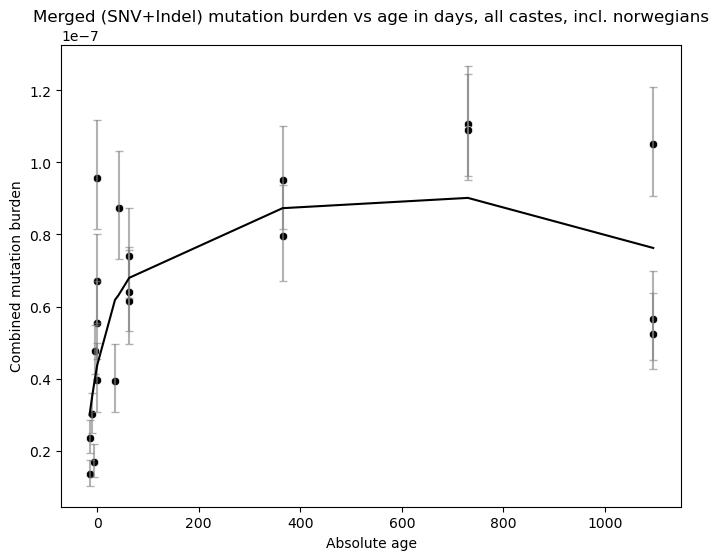

In [110]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

# Scatter
sns.scatterplot(
    data=collapsed,
    x="abs_age",
    y="burden",
    color='black'
)

# Error bars
plt.errorbar(
    collapsed["abs_age"],
    collapsed["burden"],
    yerr=[
        collapsed["burden"] - collapsed["r_low"],
        collapsed["r_high"] - collapsed["burden"]
    ],
    fmt="none",
    ecolor="gray",
    capsize=3,
    alpha=0.6
)

# Regression line (merged SNV+indel)
sns.regplot(
    data=collapsed,
    x="abs_age",
    y="burden",
    scatter=False,
    ci=95,
    lowess=True,
    color="black",
    n_boot=400,
    line_kws={"linewidth": 1.5}
)

plt.xlabel("Absolute age")
plt.ylabel("Combined mutation burden")
plt.title("Merged (SNV+Indel) mutation burden vs age in days, all castes, incl. norwegians")
#plt.savefig('./merged_mutburden_all_castes_inclNO.pdf')
#plt.savefig('./merged_mutburden_all_castes_inclNO.png')
#plt.savefig('./merged_mutburden_all_castes_inclNO.svg')
plt.show()


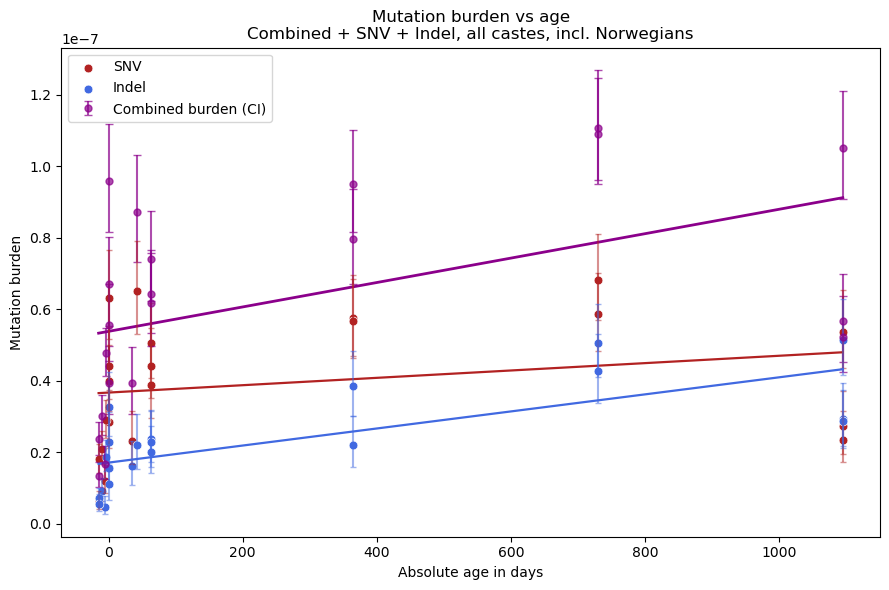

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convenience subsets
snv   = counts_all[counts_all["variant_type"] == "snv"]
indel = counts_all[counts_all["variant_type"] == "indel"]

fig, ax = plt.subplots(figsize=(9, 6))

# ================================================================
# 1) Plot COMBINED SNV+INDEL points + CI
# ================================================================
ax.errorbar(
    collapsed["abs_age"],
    collapsed["burden"],
    yerr=[
        collapsed["burden"] - collapsed["r_low"],
        collapsed["r_high"] - collapsed["burden"]
    ],
    fmt="o",
    markersize=5,
    color='darkmagenta',
    linestyle="none",
    ecolor="darkmagenta",
    capsize=3,
    alpha=0.7,
    label="Combined burden (CI)",
)

sns.regplot(
    data=collapsed,
    x="abs_age",
    y="burden",
    scatter=False,
    ci=None,
    ax=ax,
    color="darkmagenta",
    line_kws={"linewidth": 2, "label": "Combined trend"},
)

# ================================================================
# 2) Plot SNV points + CI + regression
# ================================================================
# SNV CI
ax.errorbar(
    snv["abs_age"],
    snv["burden"],
    yerr=[
        snv["burden"] - snv["r_low"],
        snv["r_high"] - snv["burden"]
    ],
    fmt="none",
    ecolor="firebrick",
    alpha=0.5,
    capsize=2
)

sns.scatterplot(
    data=snv,
    x="abs_age",
    y="burden",
    ax=ax,
    s=40,
    color="firebrick",
    label="SNV"
)

sns.regplot(
    data=snv,
    x="abs_age",
    y="burden",
    scatter=False,
    ci=None,
    ax=ax,
    color="firebrick",
    line_kws={"linewidth": 1.6, "label": "SNV trend"},
)

# ================================================================
# 3) Plot INDEL points + CI + regression
# ================================================================
ax.errorbar(
    indel["abs_age"],
    indel["burden"],
    yerr=[
        indel["burden"] - indel["r_low"],
        indel["r_high"] - indel["burden"]
    ],
    fmt="none",
    ecolor="royalblue",
    alpha=0.5,
    capsize=2
)

sns.scatterplot(
    data=indel,
    x="abs_age",
    y="burden",
    ax=ax,
    s=40,
    color="royalblue",
    label="Indel"
)

sns.regplot(
    data=indel,
    x="abs_age",
    y="burden",
    scatter=False,
    ci=None,
    ax=ax,
    color="royalblue",
    line_kws={"linewidth": 1.6, "label": "Indel trend"},
)

# ================================================================
# Final formatting
# ================================================================
ax.set_xlabel("Absolute age in days")
ax.set_ylabel("Mutation burden")
ax.set_title("Mutation burden vs age\nCombined + SNV + Indel, all castes, incl. Norwegians")
ax.legend()

#plt.savefig('./split_mutburden_all_castes_inclNO.pdf')
#plt.savefig('./split_mutburden_all_castes_inclNO.png')
#plt.savefig('./split_mutburden_all_castes_inclNO.svg')
plt.tight_layout()
plt.show()



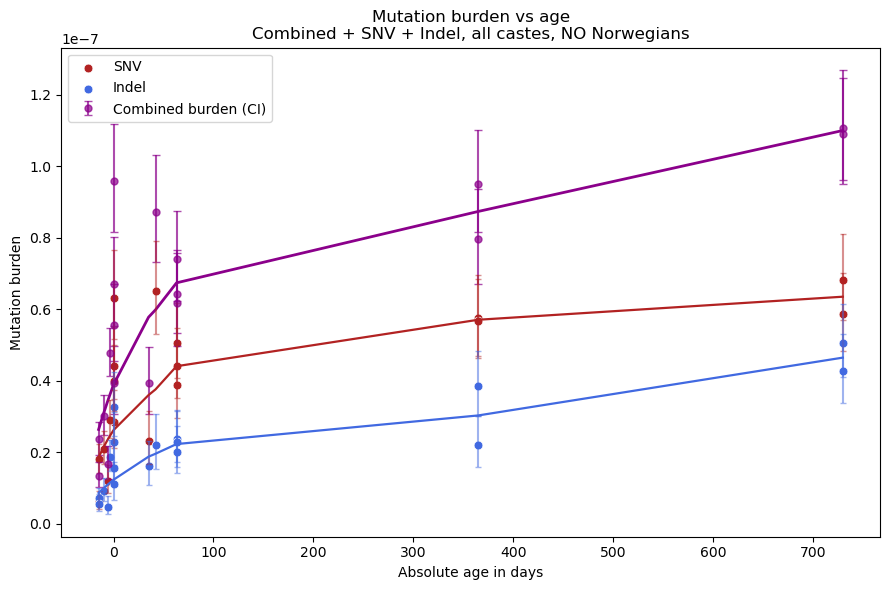

In [158]:
import matplotlib.pyplot as plt
import seaborn as sns
cc = collapsed.loc[collapsed.abs_age<800]
counts_ss = counts_all.loc[counts_all.abs_age<800]
# Convenience subsets
snv   = counts_ss[counts_ss["variant_type"] == "snv"]
indel = counts_ss[counts_ss["variant_type"] == "indel"]

fig, ax = plt.subplots(figsize=(9, 6))

# ================================================================
# 1) Plot COMBINED SNV+INDEL points + CI
# ================================================================
ax.errorbar(
    cc["abs_age"],
    cc["burden"],
    yerr=[
        cc["burden"] - cc["r_low"],
        cc["r_high"] - cc["burden"]
    ],
    fmt="o",
    markersize=5,
    color='darkmagenta',
    linestyle="none",
    ecolor="darkmagenta",
    capsize=3,
    alpha=0.7,
    label="Combined burden (CI)",
)

sns.regplot(
    data=cc,
    x="abs_age",
    y="burden",
    scatter=False,
    ci=None,
    lowess=True,
    ax=ax,
    color="darkmagenta",
    line_kws={"linewidth": 2, "label": "Combined trend"},
)

# ================================================================
# 2) Plot SNV points + CI + regression
# ================================================================
# SNV CI
ax.errorbar(
    snv["abs_age"],
    snv["burden"],
    yerr=[
        snv["burden"] - snv["r_low"],
        snv["r_high"] - snv["burden"]
    ],
    fmt="none",
    ecolor="firebrick",
    alpha=0.5,
    capsize=2
)

sns.scatterplot(
    data=snv,
    x="abs_age",
    y="burden",
    ax=ax,
    s=40,
    color="firebrick",
    label="SNV"
)

sns.regplot(
    data=snv,
    x="abs_age",
    y="burden",
    scatter=False,
    ci=None,
    lowess=True,
    ax=ax,
    color="firebrick",
    line_kws={"linewidth": 1.6, "label": "SNV trend"},
)

# ================================================================
# 3) Plot INDEL points + CI + regression
# ================================================================
ax.errorbar(
    indel["abs_age"],
    indel["burden"],
    yerr=[
        indel["burden"] - indel["r_low"],
        indel["r_high"] - indel["burden"]
    ],
    fmt="none",
    ecolor="royalblue",
    alpha=0.5,
    capsize=2
)

sns.scatterplot(
    data=indel,
    x="abs_age",
    y="burden",
    ax=ax,
    s=40,
    color="royalblue",
    label="Indel"
)

sns.regplot(
    data=indel,
    x="abs_age",
    y="burden",
    scatter=False,
    ci=None,
    lowess=True,
    ax=ax,
    color="royalblue",
    line_kws={"linewidth": 1.6, "label": "Indel trend"},
)

# ================================================================
# Final formatting
# ================================================================
ax.set_xlabel("Absolute age in days")
ax.set_ylabel("Mutation burden")
ax.set_title("Mutation burden vs age\nCombined + SNV + Indel, all castes, NO Norwegians")
ax.legend()

#plt.savefig('./split_mutburden_all_castes_inclNO.pdf')
#plt.savefig('./split_mutburden_all_castes_inclNO.png')
#plt.savefig('./split_mutburden_all_castes_inclNO.svg')
#plt.xlim(-20,800)
plt.tight_layout()
plt.show()



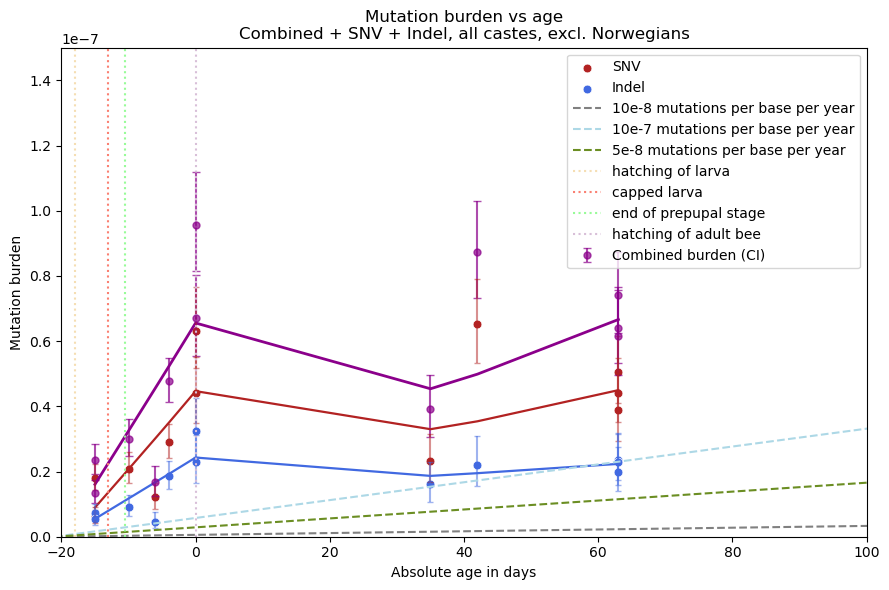

In [216]:
import matplotlib.pyplot as plt
import seaborn as sns
#cc = collapsed.loc[collapsed.abs_age<800]
#counts_ss = counts_all.loc[counts_all.abs_age<800]
cc = collapsed.loc[collapsed.caste=='W']
counts_ss = counts_all.loc[counts_all.caste=='W']
# Convenience subsets
snv   = counts_ss[counts_ss["variant_type"] == "snv"]
indel = counts_ss[counts_ss["variant_type"] == "indel"]

fig, ax = plt.subplots(figsize=(9, 6))

# ================================================================
# 1) Plot COMBINED SNV+INDEL points + CI
# ================================================================
ax.errorbar(
    cc["abs_age"],
    cc["burden"],
    yerr=[
        cc["burden"] - cc["r_low"],
        cc["r_high"] - cc["burden"]
    ],
    fmt="o",
    markersize=5,
    color='darkmagenta',
    linestyle="none",
    ecolor="darkmagenta",
    capsize=3,
    alpha=0.7,
    label="Combined burden (CI)",
)

sns.regplot(
    data=cc,
    x="abs_age",
    y="burden",
    scatter=False,
    ci=None,
    lowess=True,
    order=1,
    ax=ax,
    color="darkmagenta",
    line_kws={"linewidth": 2, "label": "Combined trend"},
)

# ================================================================
# 2) Plot SNV points + CI + regression
# ================================================================
# SNV CI
ax.errorbar(
    snv["abs_age"],
    snv["burden"],
    yerr=[
        snv["burden"] - snv["r_low"],
        snv["r_high"] - snv["burden"]
    ],
    fmt="none",
    ecolor="firebrick",
    alpha=0.5,
    capsize=2
)

sns.scatterplot(
    data=snv,
    x="abs_age",
    y="burden",
    ax=ax,
    s=40,
    color="firebrick",
    label="SNV"
)

sns.regplot(
    data=snv,
    x="abs_age",
    y="burden",
    scatter=False,
    ci=None,
    lowess=True,
    order=1,
    ax=ax,
    color="firebrick",
    line_kws={"linewidth": 1.6, "label": "SNV trend"},
)

# ================================================================
# 3) Plot INDEL points + CI + regression
# ================================================================
ax.errorbar(
    indel["abs_age"],
    indel["burden"],
    yerr=[
        indel["burden"] - indel["r_low"],
        indel["r_high"] - indel["burden"]
    ],
    fmt="none",
    ecolor="royalblue",
    alpha=0.5,
    capsize=2
)

sns.scatterplot(
    data=indel,
    x="abs_age",
    y="burden",
    ax=ax,
    s=40,
    color="royalblue",
    label="Indel"
)

sns.regplot(
    data=indel,
    x="abs_age",
    y="burden",
    scatter=False,
    ci=None,
    lowess=True,
    order=1,
    ax=ax,
    color="royalblue",
    line_kws={"linewidth": 1.6, "label": "Indel trend"},
)

a = (1e-8/365)   # slope
b = a*21   # intercept

# create x values
x = np.linspace(-21, 800 )

# compute y
y = a * x + b

ax.plot(x, y, color="grey", linestyle="dashed", label="10e-8 mutations per base per year")


a = (1e-7/365)   # slope
b = a*21   # intercept

# create x values
x = np.linspace(-21, 800 )

# compute y
y = a * x + b

ax.plot(x, y, color="lightblue", linestyle="dashed", label="10e-7 mutations per base per year")


a = (5e-8/365)   # slope
b = a*21   # intercept

# create x values
x = np.linspace(-21, 800 )

# compute y
y = a * x + b

ax.plot(x, y, color="olivedrab", linestyle="dashed", label="5e-8 mutations per base per year")




# ================================================================
# Final formatting
# ================================================================
ax.set_xlabel("Absolute age in days")
ax.set_ylabel("Mutation burden")
ax.set_title("Mutation burden vs age\nCombined + SNV + Indel, all castes, excl. Norwegians")
ax.axvline(-18, color="wheat", linestyle="dotted", label='hatching of larva')
ax.axvline(-13, color="salmon", linestyle="dotted", label='capped larva')
ax.axvline(-10.5, color="palegreen", linestyle="dotted", label='end of prepupal stage')
ax.axvline(0, color="thistle", linestyle="dotted", label='hatching of adult bee')
ax.legend()


plt.ylim(0,)

#plt.savefig('./split_mutburden_all_castes_inclNO.pdf')
#plt.savefig('./split_mutburden_all_castes_inclNO.png')
#plt.savefig('./split_mutburden_all_castes_inclNO.svg')
plt.xlim(-20,100)
plt.ylim(0,1.5e-7)
plt.tight_layout()


plt.show()



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
cc = collapsed.loc[collapsed.abs_age<800]
counts_ss = counts_all.loc[counts_all.abs_age<800]
# Convenience subsets
snv   = counts_ss[counts_ss["variant_type"] == "snv"]
indel = counts_ss[counts_ss["variant_type"] == "indel"]

fig, ax = plt.subplots(figsize=(9, 6))

# ================================================================
# 1) Plot COMBINED SNV+INDEL points + CI
# ================================================================
ax.errorbar(
    cc["abs_age"],
    cc["burden"],
    yerr=[
        cc["burden"] - cc["r_low"],
        cc["r_high"] - cc["burden"]
    ],
    fmt="o",
    markersize=5,
    color='darkmagenta',
    linestyle="none",
    ecolor="darkmagenta",
    capsize=3,
    alpha=0.7,
    label="Combined burden (CI)",
)

sns.regplot(
    data=cc,
    x="abs_age",
    y="burden",
    scatter=False,
    ci=None,
    lowess=True,
    order=1,
    ax=ax,
    color="darkmagenta",
    line_kws={"linewidth": 2, "label": "Combined trend"},
)

# ================================================================
# 2) Plot SNV points + CI + regression
# ================================================================
# SNV CI
ax.errorbar(
    snv["abs_age"],
    snv["burden"],
    yerr=[
        snv["burden"] - snv["r_low"],
        snv["r_high"] - snv["burden"]
    ],
    fmt="none",
    ecolor="firebrick",
    alpha=0.5,
    capsize=2
)

sns.scatterplot(
    data=snv,
    x="abs_age",
    y="burden",
    ax=ax,
    s=40,
    color="firebrick",
    label="SNV"
)

sns.regplot(
    data=snv,
    x="abs_age",
    y="burden",
    scatter=False,
    ci=None,
    lowess=True,
    order=1,
    ax=ax,
    color="firebrick",
    line_kws={"linewidth": 1.6, "label": "SNV trend"},
)

# ================================================================
# 3) Plot INDEL points + CI + regression
# ================================================================
ax.errorbar(
    indel["abs_age"],
    indel["burden"],
    yerr=[
        indel["burden"] - indel["r_low"],
        indel["r_high"] - indel["burden"]
    ],
    fmt="none",
    ecolor="royalblue",
    alpha=0.5,
    capsize=2
)

sns.scatterplot(
    data=indel,
    x="abs_age",
    y="burden",
    ax=ax,
    s=40,
    color="royalblue",
    label="Indel"
)

sns.regplot(
    data=indel,
    x="abs_age",
    y="burden",
    scatter=False,
    ci=None,
    lowess=True,
    order=1,
    ax=ax,
    color="royalblue",
    line_kws={"linewidth": 1.6, "label": "Indel trend"},
)

a = (1e-8/365)   # slope
b = 0   # intercept

# create x values
x = np.linspace(0, 800 )

# compute y
y = a * x + b

ax.plot(x, y, color="grey", linestyle="dashed", label="10e-8 mutations per base per year")


a = (1e-7/365)   # slope
b = 0   # intercept

# create x values
x = np.linspace(0, 800 )

# compute y
y = a * x + b

ax.plot(x, y, color="lightblue", linestyle="dashed", label="10e-7 mutations per base per year")


a = (5e-8/365)   # slope
b = 0   # intercept

# create x values
x = np.linspace(0, 800 )

# compute y
y = a * x + b

ax.plot(x, y, color="lightgreen", linestyle="dashed", label="5e-8 mutations per base per year")




# ================================================================
# Final formatting
# ================================================================
ax.set_xlabel("Absolute age in days")
ax.set_ylabel("Mutation burden")
ax.set_title("Mutation burden vs age\nCombined + SNV + Indel, all castes, excl. Norwegians")
ax.legend()
ax.axvline(0, color="grey", linestyle="dashed")

plt.ylim(0,)

#plt.savefig('./split_mutburden_all_castes_inclNO.pdf')
#plt.savefig('./split_mutburden_all_castes_inclNO.png')
#plt.savefig('./split_mutburden_all_castes_inclNO.svg')
#plt.xlim(-20,500)
plt.tight_layout()

plt.show()



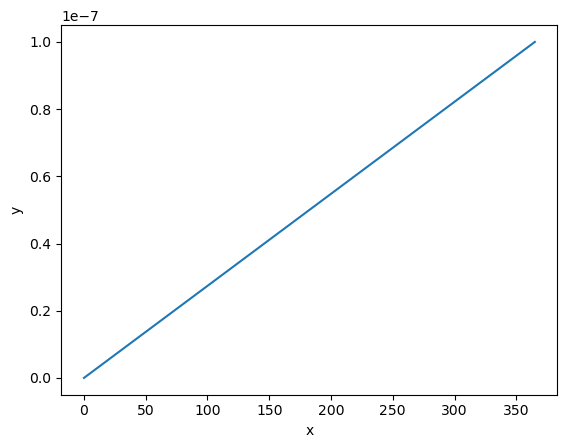

In [133]:
a = (10e-8/365)   # slope
b = 0   # intercept

# create x values
x = np.linspace(0, 365, 730, 1095)

# compute y
y = a * x + b

# plot
plt.plot(x, y)
plt.xlabel("x")
plt.ylabel("y")
plt.show()

In [ ]:
(10-8/365)

In [156]:
counts_all["burden_genome"] = counts_all["burden"]*2.252e8

In [157]:
counts_all["burden_genome"]

0      3.502033
1      8.988551
2      2.503356
3      6.383557
4      5.156964
5      9.927155
6      7.323668
7     14.240465
8      3.612630
9      5.232085
10     4.984319
11    14.668139
12     5.328525
13    11.367520
14     4.499440
15     9.946131
16     5.131463
17     8.753672
18     9.592457
19    15.347931
20     4.973954
21    12.932280
22     8.662883
23    12.753689
24    11.578910
25    12.066443
26     6.596174
27     6.146435
28     6.479215
29     5.301176
30    11.379313
31    13.181977
0      2.061645
1      4.712331
2      1.046946
3      2.722060
4      4.196347
5      6.539762
6      1.611499
7      1.410062
8      1.254778
9      4.065482
Name: burden_genome, dtype: float64

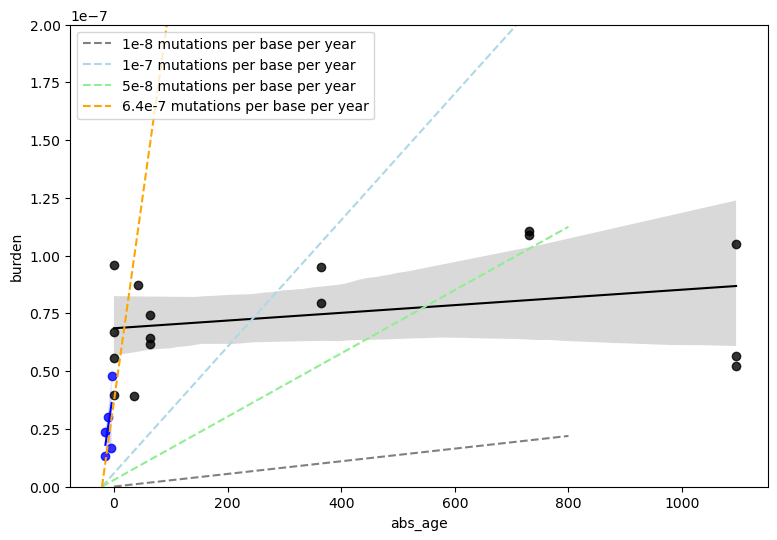

In [189]:
fig, ax = plt.subplots(figsize=(9, 6))
sns.regplot(
    data=collapsed.loc[collapsed.abs_age>=0],
    x="abs_age",
    y="burden",
    scatter=True,
    lowess=False,
    color="black",
    n_boot=400,
    ax=ax,
    line_kws={"linewidth": 1.5}
)

sns.regplot(
    data=collapsed.loc[collapsed.abs_age<0],
    x="abs_age",
    y="burden",
    scatter=True,
    lowess=False,
    color="blue",
    n_boot=400,
    ax=ax,
    line_kws={"linewidth": 1.5}
)



a = (1e-8/365)   # slope
b = 0   # intercept

# create x values
x = np.linspace(0, 800 )

# compute y
y = a * x + b

ax.plot(x, y, color="grey", linestyle="dashed", label="1e-8 mutations per base per year")


a = (1e-7/365)   # slope
b = a*21   # intercept

# create x values
x = np.linspace(-21, 800 )

# compute y
y = a * x + b

ax.plot(x, y, color="lightblue", linestyle="dashed", label="1e-7 mutations per base per year")


a = (5e-8/365)   # slope
b = a*21   # intercept

# create x values
x = np.linspace(-21, 800 )

# compute y
y = a * x + b

ax.plot(x, y, color="lightgreen", linestyle="dashed", label="5e-8 mutations per base per year")


a = (6.4e-7/365)   # slope
b = a*21   # intercept

# create x values
x = np.linspace(-21, 800 )

# compute y
y = a * x + b

ax.plot(x, y, color="orange", linestyle="dashed", label="6.4e-7 mutations per base per year")

ax.legend()
#ax.set_xlim(-21,60)
ax.set_ylim(0,0.2e-6)
plt.show()


In [190]:
cc = collapsed.loc[collapsed.caste=='W']
counts_ss = counts_all.loc[counts_all.caste=='W']

,sample,variant_type,count,age,abs_age,caste,Number of Read Families,Number of Pass-filter Reads,Number of Effective Read Families,Effective Coverage,Per Read Family Coverage,Pass-filter Duplication Rate,Efficiency,burden
0,11d1,indel,35,-10,-10,W,589368551.0,9.541345e+08,73841570.0,3.823161e+09,51.775183,0.382300,0.068588,9.154729e-09
1,11d1,snv,80,-10,-10,W,589368551.0,9.541345e+08,73841570.0,3.823161e+09,51.775183,0.382300,0.068588,2.092509e-08
2,15d1,indel,15,-6,-6,W,517935770.0,8.508448e+08,60998394.0,3.226527e+09,52.895273,0.391269,0.063170,4.648962e-09
3,15d1,snv,39,-6,-6,W,517935770.0,8.508448e+08,60998394.0,3.226527e+09,52.895273,0.391269,0.063170,1.208730e-08
4,17d1,indel,77,-4,-4,W,570160471.0,1.015542e+09,79633134.0,4.132261e+09,51.891222,0.438565,0.069669,1.863387e-08
5,17d1,snv,120,-4,-4,W,570160471.0,1.015542e+09,79633134.0,4.132261e+09,51.891222,0.438565,0.069669,2.903979e-08
6,6d1,indel,32,-15,-15,W,591046717.0,1.010014e+09,80352438.0,4.471861e+09,55.653086,0.414813,0.069645,7.155857e-09
7,6d1,snv,28,-15,-15,W,591046717.0,1.010014e+09,80352438.0,4.471861e+09,55.653086,0.414813,0.069645,6.261375e-09
8,6d2,indel,25,-15,-15,W,600780063.0,1.037768e+09,80392111.0,4.486848e+09,55.812049,0.421085,0.068688,5.571840e-09
9,6d2,snv,81,-15,-15,W,600780063.0,1.037768e+09,80392111.0,4.486848e+09,55.812049,0.421085,0.068688,1.805276e-08


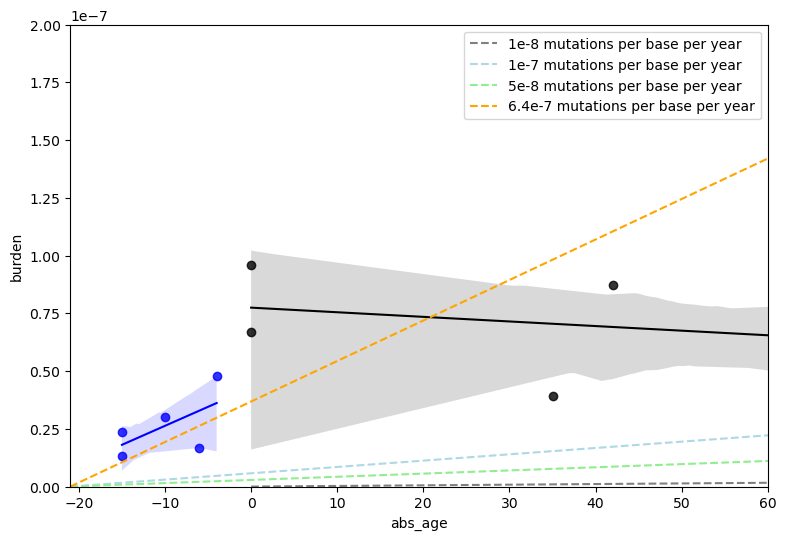

In [220]:
fig, ax = plt.subplots(figsize=(9, 6))
cc = collapsed.loc[collapsed.caste=='W']

sns.regplot(
    data=cc.loc[cc.abs_age>=0],
    x="abs_age",
    y="burden",
    scatter=True,
    lowess=False,
    color="black",
    n_boot=400,
    ax=ax,
    line_kws={"linewidth": 1.5}
)

sns.regplot(
    data=cc.loc[cc.abs_age<0],
    x="abs_age",
    y="burden",
    scatter=True,
    lowess=False,
    color="blue",
    n_boot=400,
    ax=ax,
    line_kws={"linewidth": 1.5}
)



a = (1e-8/365)   # slope
b = 0   # intercept

# create x values
x = np.linspace(0, 800 )

# compute y
y = a * x + b

ax.plot(x, y, color="grey", linestyle="dashed", label="1e-8 mutations per base per year")


a = (1e-7/365)   # slope
b = a*21   # intercept

# create x values
x = np.linspace(-21, 800 )

# compute y
y = a * x + b

ax.plot(x, y, color="lightblue", linestyle="dashed", label="1e-7 mutations per base per year")


a = (5e-8/365)   # slope
b = a*21   # intercept

# create x values
x = np.linspace(-21, 800 )

# compute y
y = a * x + b

ax.plot(x, y, color="lightgreen", linestyle="dashed", label="5e-8 mutations per base per year")


a = (6.4e-7/365)   # slope
b = a*21   # intercept

# create x values
x = np.linspace(-21, 800 )

# compute y
y = a * x + b

ax.plot(x, y, color="orange", linestyle="dashed", label="6.4e-7 mutations per base per year")

ax.legend()
ax.set_xlim(-21,60)
ax.set_ylim(0,0.2e-6)
plt.show()


In [222]:
import statsmodels.formula.api as sm

In [230]:
collapsed['agezero'] = collapsed['abs_age']+21

In [414]:
# joint fit across all individuals - fit through origin

model = sm.ols('burden ~ 0 + agezero' ,data=collapsed.loc[collapsed.abs_age>=0])
mfit = model.fit()
mfit.summary()

/home/tilman/miniforge3/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=16 observations were given.
  return hypotest_fun_in(*args, **kwds)


<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                 burden   R-squared (uncentered):                   0.497
Model:                            OLS   Adj. R-squared (uncentered):              0.463
Method:                 Least Squares   F-statistic:                              14.81
Date:                Thu, 12 Mar 2026   Prob (F-statistic):                     0.00158
Time:                        15:49:27   Log-Likelihood:                          244.65
No. Observations:                  16   AIC:                                     -487.3
Df Residuals:                      15   BIC:                                     -486.5
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
agezero      9.65e-11   2.51e-11      3.848      0.002     4.3e-11     1.5e-10
==============================================================================
Omnibus:                        6.916   Durbin-Watson:                   0.469
Prob(Omnibus):                  0.031   Jarque-Bera (JB):                4.165
Skew:                          -1.203   Prob(JB):                        0.125
Kurtosis:                       3.678   Cond. No.                         1.00
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [269]:
collapsed.loc[collapsed.agezero<=21]

,sample,count,Effective Coverage,burden,r_low,r_high,abs_age,caste,agezero
0,0dQ5,107,1.929165e+09,5.546440e-08,4.545442e-08,6.702305e-08,0,Q,21
1,0dQ6,71,1.799185e+09,3.946231e-08,3.082039e-08,4.977634e-08,0,Q,21
2,0dW8,117,1.746764e+09,6.698099e-08,5.539510e-08,8.027496e-08,0,W,21
3,0dW9,159,1.660480e+09,9.575547e-08,8.145005e-08,1.118502e-07,0,W,21
4,11d1,115,3.823161e+09,3.007982e-08,2.483398e-08,3.610627e-08,-10,W,11
5,15d1,54,3.226527e+09,1.673626e-08,1.257280e-08,2.183719e-08,-6,W,15
6,17d1,197,4.132261e+09,4.767366e-08,4.124852e-08,5.481594e-08,-4,W,17
8,6d1,60,4.471861e+09,1.341723e-08,1.023876e-08,1.727064e-08,-15,W,6
9,6d2,106,4.486848e+09,2.362460e-08,1.934189e-08,2.857327e-08,-15,W,6


In [410]:
import scipy as sc

In [415]:
adults = collapsed.loc[collapsed.abs_age>=0]
queens = adults.loc[adults.caste=='Q'].burden
workers = adults.loc[adults.caste=='W'].burden

<Axes: xlabel='caste', ylabel='burden'>

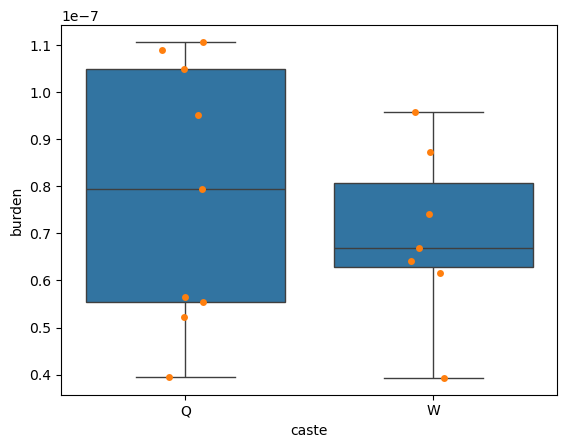

In [421]:
sns.boxplot(x='caste', y='burden',data=adults)
sns.stripplot(x='caste', y='burden',data=adults)

In [419]:
sc.stats.ttest_ind(queens, workers)

TtestResult(statistic=np.float64(0.6760716058053605), pvalue=np.float64(0.510010137002606), df=np.float64(14.0))

In [440]:
young_adults = collapsed.loc[collapsed.abs_age>=0].loc[collapsed.abs_age<=100]
young_queens = young_adults.loc[young_adults.caste=='Q'].burden
young_workers = young_adults.loc[young_adults.caste=='W'].burden

In [441]:
collapsed

,sample,count,Effective Coverage,burden,r_low,r_high,abs_age,caste,agezero,stage
0,0dQ5,107,1.929165e+09,5.546440e-08,4.545442e-08,6.702305e-08,0,Q,21,adult
1,0dQ6,71,1.799185e+09,3.946231e-08,3.082039e-08,4.977634e-08,0,Q,21,adult
2,0dW8,117,1.746764e+09,6.698099e-08,5.539510e-08,8.027496e-08,0,W,21,adult
3,0dW9,159,1.660480e+09,9.575547e-08,8.145005e-08,1.118502e-07,0,W,21,adult
4,11d1,115,3.823161e+09,3.007982e-08,2.483398e-08,3.610627e-08,-10,W,11,pupa
5,15d1,54,3.226527e+09,1.673626e-08,1.257280e-08,2.183719e-08,-6,W,15,pupa
6,17d1,197,4.132261e+09,4.767366e-08,4.124852e-08,5.481594e-08,-4,W,17,pupa
7,5wW2,71,1.807769e+09,3.927494e-08,3.067405e-08,4.953999e-08,35,W,56,adult
8,6d1,60,4.471861e+09,1.341723e-08,1.023876e-08,1.727064e-08,-15,W,6,larva_uncapped
9,6d2,106,4.486848e+09,2.362460e-08,1.934189e-08,2.857327e-08,-15,W,6,larva_uncapped


In [442]:
young_adults

,sample,count,Effective Coverage,burden,r_low,r_high,abs_age,caste,agezero,stage
0,0dQ5,107,1.929165e+09,5.546440e-08,4.545442e-08,6.702305e-08,0,Q,21,adult
1,0dQ6,71,1.799185e+09,3.946231e-08,3.082039e-08,4.977634e-08,0,Q,21,adult
2,0dW8,117,1.746764e+09,6.698099e-08,5.539510e-08,8.027496e-08,0,W,21,adult
3,0dW9,159,1.660480e+09,9.575547e-08,8.145005e-08,1.118502e-07,0,W,21,adult
7,5wW2,71,1.807769e+09,3.927494e-08,3.067405e-08,4.953999e-08,35,W,56,adult
10,6wW2,138,1.581359e+09,8.726669e-08,7.331471e-08,1.031010e-07,42,W,63,adult
11,9wW1,141,1.901840e+09,7.413874e-08,6.240686e-08,8.743530e-08,63,W,84,adult
12,9wW2,122,1.901926e+09,6.414552e-08,5.326898e-08,7.658984e-08,63,W,84,adult
13,9wW3,92,1.492128e+09,6.165690e-08,4.970417e-08,7.561672e-08,63,W,84,adult


In [443]:
sc.stats.ttest_ind(young_queens, young_workers)

TtestResult(statistic=np.float64(-1.5908870749939716), pvalue=np.float64(0.15566102218507386), df=np.float64(7.0))

<Axes: xlabel='caste', ylabel='burden'>

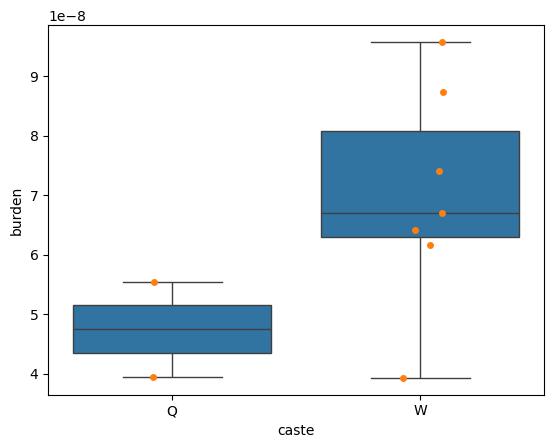

In [444]:
sns.boxplot(x='caste', y='burden',data=young_adults)
#sns.stripplot(x='caste', y='burden',data=young_adults)

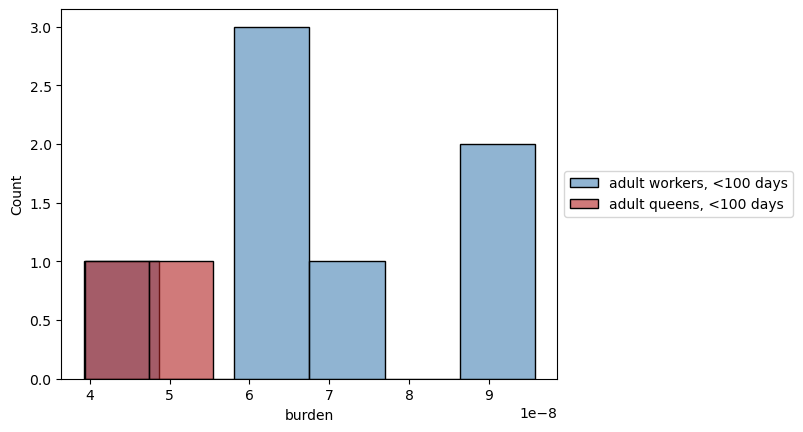

In [522]:
sns.histplot(young_workers, binwidth=1e-8, alpha=0.6, color='steelblue',label='adult workers, <100 days')
sns.histplot(young_queens, binwidth=1e-8, alpha=0.6, color='firebrick',label='adult queens, <100 days')
plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))


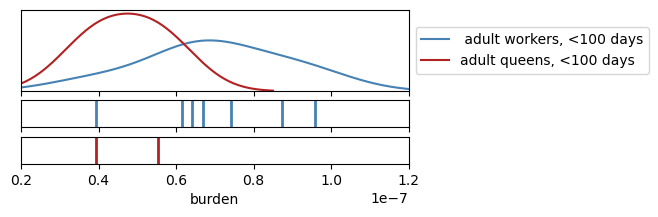

In [520]:
fig, (ax, ax1, ax2) = plt.subplots(ncols=1, nrows=3, figsize=[5,2], sharex=True, gridspec_kw={'height_ratios': [3, 1, 1]})
sns.kdeplot(young_workers, color='steelblue', label=' adult workers, <100 days', ax=ax)
sns.kdeplot(young_queens, color='firebrick' , ax=ax, label='adult queens, <100 days')

sns.rugplot(young_workers, linewidth=2, height=1, color='steelblue', ax=ax1)
sns.rugplot(young_queens, linewidth=2, height=1, color='firebrick', ax=ax2)
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))
ax.set_ylabel('')
ax.set_yticks([])
ax1.set_yticks([])
ax2.set_yticks([])

ax2.set_xlim(0.2e-7, 1.2e-7)
plt.show()

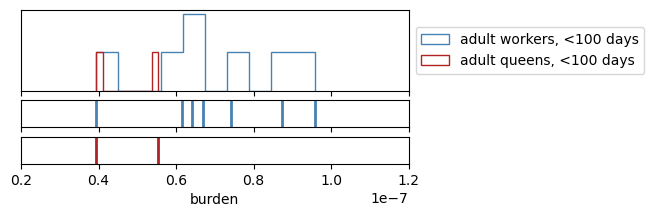

In [521]:
fig, (ax, ax1, ax2) = plt.subplots(ncols=1, nrows=3, figsize=[5,2], sharex=True, gridspec_kw={'height_ratios': [3, 1, 1]})
ax.hist(young_workers, color='steelblue', lw=1, label='adult workers, <100 days', histtype="step")
ax.hist(young_queens, color='firebrick',lw=1, label='adult queens, <100 days', histtype="step")

sns.rugplot(young_workers, linewidth=2, height=1, color='steelblue', ax=ax1)
sns.rugplot(young_queens, linewidth=2, height=1, color='firebrick', ax=ax2)
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))
ax.set_ylabel('')
ax.set_yticks([])
ax1.set_yticks([])
ax2.set_yticks([])

ax2.set_xlim(0.2e-7, 1.2e-7)
plt.show()

In [ ]:
all_workers = collapsed.loc[collapsed.caste=='W']
baby_workers = all_workers.loc[all_workers.abs_age<0]
adult_workers = all_workers.loc[all_workers.abs_age>=0]

In [428]:
sc.stats.ttest_ind(baby_workers.burden, adult_workers.burden)

TtestResult(statistic=np.float64(-4.471089809711957), pvalue=np.float64(0.0011954027983782152), df=np.float64(10.0))

In [446]:
#sns.boxplot(x=[1 for i in baby_workers], y=baby_workers)
#sns.stripplot(x='caste', y='burden',data=young_adults)

In [273]:
model = sm.ols("burden ~ 0 + agezero", data=collapsed.loc[collapsed.agezero<=21]).fit()
model.summary()


/home/tilman/miniforge3/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=9 observations were given.
  return hypotest_fun_in(*args, **kwds)


<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                 burden   R-squared (uncentered):                   0.888
Model:                            OLS   Adj. R-squared (uncentered):              0.874
Method:                 Least Squares   F-statistic:                              63.67
Date:                Thu, 12 Mar 2026   Prob (F-statistic):                    4.45e-05
Time:                        13:39:46   Log-Likelihood:                          148.40
No. Observations:                   9   AIC:                                     -294.8
Df Residuals:                       8   BIC:                                     -294.6
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
agezero     2.843e-09   3.56e-10      7.979      0.000    2.02e-09    3.66e-09
==============================================================================
Omnibus:                        2.996   Durbin-Watson:                   1.829
Prob(Omnibus):                  0.224   Jarque-Bera (JB):                0.674
Skew:                           0.639   Prob(JB):                        0.714
Kurtosis:                       3.407   Cond. No.                         1.00
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [280]:
model = sm.ols('burden ~ agezero' ,data=collapsed.loc[collapsed.agezero>=21])
mfit = model.fit()
mfit.summary()

/home/tilman/miniforge3/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=16 observations were given.
  return hypotest_fun_in(*args, **kwds)


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 burden   R-squared:                       0.095
Model:                            OLS   Adj. R-squared:                  0.030
Method:                 Least Squares   F-statistic:                     1.468
Date:                Thu, 12 Mar 2026   Prob (F-statistic):              0.246
Time:                        13:52:26   Log-Likelihood:                 259.49
No. Observations:                  16   AIC:                            -515.0
Df Residuals:                      14   BIC:                            -513.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   6.819e-08   7.85e-09      8.684      0.000    5.13e-08     8.5e-08
agezero      1.67e-11   1.38e-11      1.212      0.246   -1.29e-11    4.63e-11
==============================================================================
Omnibus:                        3.209   Durbin-Watson:                   2.126
Prob(Omnibus):                  0.201   Jarque-Bera (JB):                1.252
Skew:                          -0.192   Prob(JB):                        0.535
Kurtosis:                       1.684   Cond. No.                         764.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [375]:
# splitting lines
a_max = 1/365
a_1 = 1e-6/365
a_2 = 5e-7/365
a_3 = 1e-7/365
a_4 = 5e-8/365
a_5 = 1e-8/365
a_min = 0

In [345]:
a_1

2.73972602739726e-09

In [281]:
1.67e-11*365

6.095500000000001e-09

In [379]:
stage = []
for i in collapsed.agezero:
    if i<4:
        stage.append('egg')
    elif i<9:
        stage.append('larva_uncapped')
    elif i<11:
        stage.append('larva_capped')
    elif i<21:
        stage.append('pupa')
    else: 
        stage.append("adult")

In [380]:
collapsed['stage'] = stage

In [381]:
collapsed

,sample,count,Effective Coverage,burden,r_low,r_high,abs_age,caste,agezero,stage
0,0dQ5,107,1.929165e+09,5.546440e-08,4.545442e-08,6.702305e-08,0,Q,21,adult
1,0dQ6,71,1.799185e+09,3.946231e-08,3.082039e-08,4.977634e-08,0,Q,21,adult
2,0dW8,117,1.746764e+09,6.698099e-08,5.539510e-08,8.027496e-08,0,W,21,adult
3,0dW9,159,1.660480e+09,9.575547e-08,8.145005e-08,1.118502e-07,0,W,21,adult
4,11d1,115,3.823161e+09,3.007982e-08,2.483398e-08,3.610627e-08,-10,W,11,pupa
5,15d1,54,3.226527e+09,1.673626e-08,1.257280e-08,2.183719e-08,-6,W,15,pupa
6,17d1,197,4.132261e+09,4.767366e-08,4.124852e-08,5.481594e-08,-4,W,17,pupa
7,5wW2,71,1.807769e+09,3.927494e-08,3.067405e-08,4.953999e-08,35,W,56,adult
8,6d1,60,4.471861e+09,1.341723e-08,1.023876e-08,1.727064e-08,-15,W,6,larva_uncapped
9,6d2,106,4.486848e+09,2.362460e-08,1.934189e-08,2.857327e-08,-15,W,6,larva_uncapped


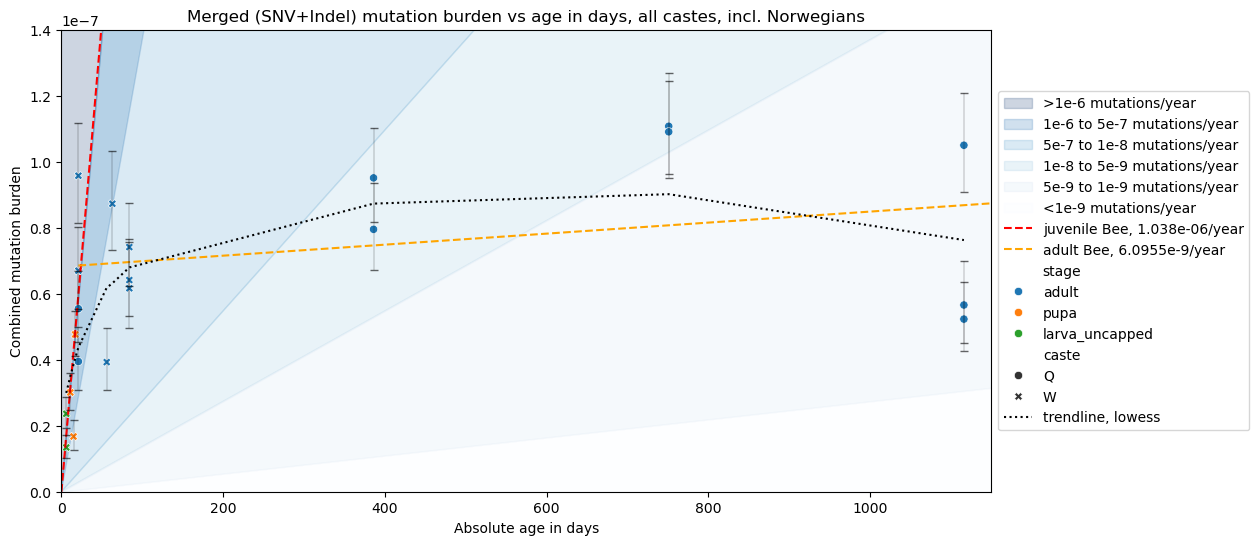

In [382]:
import seaborn as sns
import matplotlib.pyplot as plt


fig, ax = plt.subplots(ncols=1,nrows=1, figsize=(12,6))




x = np.linspace(0, 1200, 1200)
cmap = plt.get_cmap("Blues_r")
colors = cmap(np.linspace(0, 1, 6))
alpha=0.2


y2 = a_2 * x
ax.fill_between(x, y1, y2, color=colors[1], alpha=alpha, label='1e-6 to 5e-7 mutations/year')

y3 = a_3 * x
ax.fill_between(x, y1, y3, color=colors[2], alpha=alpha, label='5e-7 to 1e-8 mutations/year')

y4 = a_4 * x
ax.fill_between(x, y3, y4, color=colors[3], alpha=alpha, label='1e-8 to 5e-9 mutations/year')

y5 = a_5 * x
ax.fill_between(x, y4, y5, color=colors[4], alpha=alpha, label='5e-9 to 1e-9 mutations/year')

y_min = a_min * x
ax.fill_between(x,y5,y_min, color=colors[5], alpha=alpha, label='<1e-9 mutations/year')
#plt.xlabel("Age")
#plt.ylabel("Mutation burden")


a = 2.843e-09   # slope
b =  0 # assuming intercept at zero
x = np.linspace(0, 50 )
y = a * x + b
ax.plot(x, y, color="red", linestyle="dashed", label="juvenile Bee, 1.038e-06/year")

a = 1.67e-11   # slope
b =  6.819e-08  # intercept
x = np.linspace(21, 1150 )
y = a * x + b
ax.plot(x, y, color="orange", linestyle="dashed", label="adult Bee, 6.0955e-9/year")



# Scatter
sns.scatterplot(
    data=collapsed,
    x="agezero",
    y="burden",
    palette='tab10',
    style='caste',
    hue='stage',
    ax=ax
)

# Error bars
ax.errorbar(
    collapsed["agezero"],
    collapsed["burden"],
    yerr=[
        collapsed["burden"] - collapsed["r_low"],
        collapsed["r_high"] - collapsed["burden"]
    ],
    fmt="none",
    ecolor="black",
    capsize=3,
    alpha=0.6,
    linewidth=0.3,
)

# Regression line (merged SNV+indel)
sns.regplot(
    data=collapsed,
    x="agezero",
    y="burden",
    scatter=False,
    ci=95,
    lowess=True,
    color="black",
    n_boot=400,
    line_kws={"linewidth": 1.5, 'linestyle':'dotted'},
    ax=ax,
    label = 'trendline, lowess'
)

#ax.axhline(2.843e-09*22, color='lightgrey', linestyle='dotted')
#ax.axhline(6.819e-08, color='lightgrey', linestyle='dotted')


y1 = a_1 * x
ax.fill_between(x, y1_max, y1, color=colors[0], alpha=alpha, label='>1e-6 mutations/year')

y2 = a_2 * x
ax.fill_between(x, y1, y2, color=colors[1], alpha=alpha, label='1e-6 to 5e-7 mutations/year')

y3 = a_3 * x
ax.fill_between(x, y1, y3, color=colors[2], alpha=alpha, label='5e-7 to 1e-8 mutations/year')

y4 = a_4 * x
ax.fill_between(x, y3, y4, color=colors[3], alpha=alpha, label='1e-8 to 5e-9 mutations/year')

y5 = a_5 * x
ax.fill_between(x, y4, y5, color=colors[4], alpha=alpha, label='5e-9 to 1e-9 mutations/year')

y_min = a_min * x
ax.fill_between(x,y5,y_min, color=colors[5], alpha=alpha, label='<1e-9 mutations/year')




#ax.set_xlim(0,200)
ax.set_xlim(0,1150)
ax.set_ylim(0,1.4e-7)
ax.set_xlabel("Absolute age in days")
ax.set_ylabel("Combined mutation burden")
plt.title("Merged (SNV+Indel) mutation burden vs age in days, all castes, incl. Norwegians")
plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))
#plt.savefig('./merged_mutburden_all_castes_inclNO.pdf')
#plt.savefig('./merged_mutburden_all_castes_inclNO.png')
#plt.savefig('./merged_mutburden_all_castes_inclNO.svg')
plt.show()


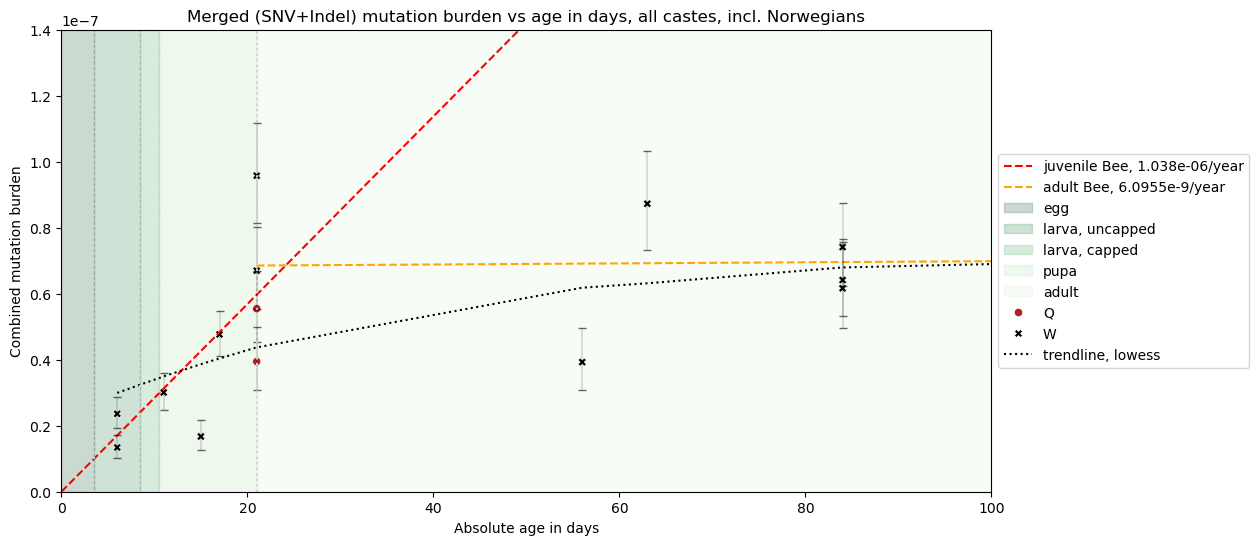

In [409]:
import seaborn as sns
import matplotlib.pyplot as plt


fig, ax = plt.subplots(ncols=1,nrows=1, figsize=(12,6))


a = 2.843e-09   # slope
b =  0 # assuming intercept at zero
x = np.linspace(0, 50 )
y = a * x + b
ax.plot(x, y, color="red", linestyle="dashed", label="juvenile Bee, 1.038e-06/year")

a = 1.67e-11   # slope
b =  6.819e-08  # intercept
x = np.linspace(21, 1150 )
y = a * x + b
ax.plot(x, y, color="orange", linestyle="dashed", label="adult Bee, 6.0955e-9/year")

cmap = plt.get_cmap("Greens_r")
colors = cmap(np.linspace(0, 1, 7))
alpha=0.2


ax.axvspan(0,3.5, color=colors[0], alpha=alpha, label='egg')

ax.axvspan(3.5,8.5, color=colors[1], alpha=alpha,label='larva, uncapped')

ax.axvspan(8.5,10.5, color=colors[2], alpha=alpha,label='larva, capped')

ax.axvspan(10.5,21, color=colors[4], alpha=alpha,label='pupa')
ax.axvspan(21,2000, color=colors[5], alpha=alpha,label='adult')



# Scatter
sns.scatterplot(
    data=collapsed,
    x="agezero",
    y="burden",
    color='black',
    style='caste',
    hue='caste',
    palette=['firebrick', 'black'],
    ax=ax
)

# Error bars
ax.errorbar(
    collapsed["agezero"],
    collapsed["burden"],
    yerr=[
        collapsed["burden"] - collapsed["r_low"],
        collapsed["r_high"] - collapsed["burden"]
    ],
    fmt="none",
    ecolor="black",
    capsize=3,
    alpha=0.6,
    linewidth=0.3,
)

# Regression line (merged SNV+indel)
sns.regplot(
    data=collapsed,
    x="agezero",
    y="burden",
    scatter=False,
    ci=95,
    lowess=True,
    color="black",
    n_boot=400,
    line_kws={"linewidth": 1.5, 'linestyle':'dotted'},
    ax=ax,
    label = 'trendline, lowess'
)

ax.axvline(3.5, color='lightgrey', linestyle='dotted') # egg
ax.axvline(8.5, color='lightgrey', linestyle='dotted') # uncapped larva
ax.axvline(10.5, color='lightgrey', linestyle='dotted') # capped larva
ax.axvline(21, color='lightgrey', linestyle='dotted') # adult






ax.set_xlim(0,100)
#ax.set_xlim(0,1150)
ax.set_ylim(0,1.4e-7)
ax.set_xlabel("Absolute age in days")
ax.set_ylabel("Combined mutation burden")
plt.title("Merged (SNV+Indel) mutation burden vs age in days, all castes, incl. Norwegians")
plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))
#plt.savefig('./merged_mutburden_all_castes_inclNO.pdf')
#plt.savefig('./merged_mutburden_all_castes_inclNO.png')
#plt.savefig('./merged_mutburden_all_castes_inclNO.svg')
plt.show()


In [287]:
2.843e-09*21

5.9703e-08

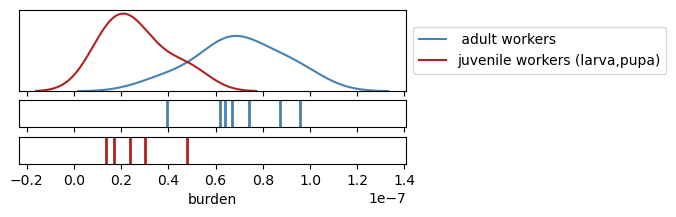

In [526]:
all_workers = collapsed.loc[collapsed.caste=='W']
baby_workers = all_workers.loc[all_workers.abs_age<0]
adult_workers = all_workers.loc[all_workers.abs_age>=0]


fig, (ax, ax1, ax2) = plt.subplots(ncols=1, nrows=3, figsize=[5,2], sharex=True, gridspec_kw={'height_ratios': [3, 1, 1]})
sns.kdeplot(adult_workers.burden, color='steelblue', label=' adult workers', ax=ax)
sns.kdeplot(baby_workers.burden, color='firebrick' , ax=ax, label='juvenile workers (larva,pupa)')

sns.rugplot(adult_workers.burden, linewidth=2, height=1, color='steelblue', ax=ax1)
sns.rugplot(baby_workers.burden, linewidth=2, height=1, color='firebrick', ax=ax2)
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))
ax.set_ylabel('')
ax.set_yticks([])
ax1.set_yticks([])
ax2.set_yticks([])

#ax2.set_xlim(0.2e-7, 1.2e-7)
plt.show()

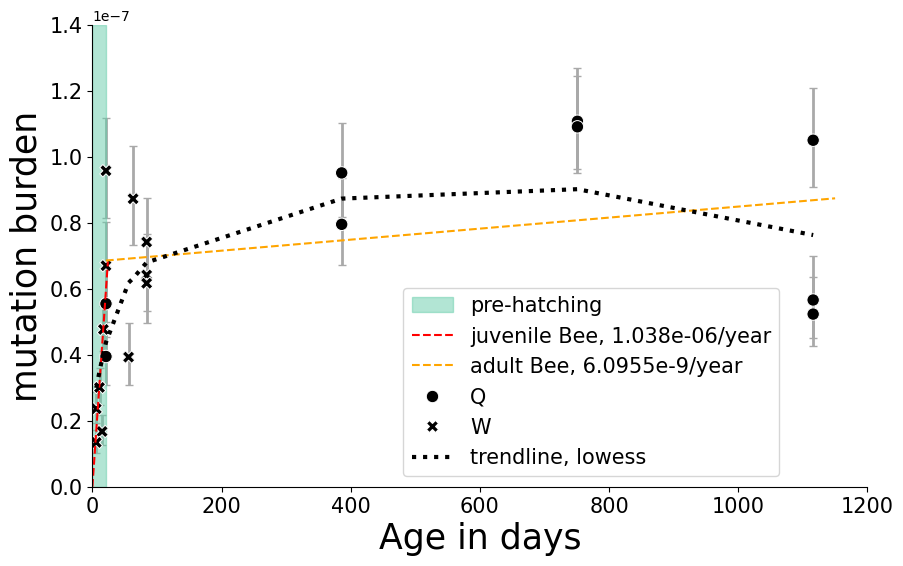

In [582]:
import seaborn as sns
import matplotlib.pyplot as plt


fig, ax = plt.subplots(ncols=1,nrows=1, figsize=(10,6))

ax.axvspan(0,21, color='mediumaquamarine', alpha=0.5, label='pre-hatching')
#ax.axvline(21, color='lightgrey', linestyle='dotted', label='hatching of workers')


a = 2.843e-09   # slope
b =  0 # assuming intercept at zero
x = np.linspace(0, 24 )
y = a * x + b
ax.plot(x, y, color="red", linestyle="dashed", label="juvenile Bee, 1.038e-06/year")

a = 1.67e-11   # slope
b =  6.819e-08  # intercept
x = np.linspace(21, 1150 )
y = a * x + b
ax.plot(x, y, color="orange", linestyle="dashed", label="adult Bee, 6.0955e-9/year")

# Error bars
ax.errorbar(
    collapsed["agezero"],
    collapsed["burden"],
    yerr=[
        collapsed["burden"] - collapsed["r_low"],
        collapsed["r_high"] - collapsed["burden"]
    ],
    fmt="none",
    ecolor="darkgrey",
    capsize=3,
    alpha=1,
    linewidth=2,
    zorder=-300
)

# Scatter
sns.scatterplot(
    data=collapsed,
    x="agezero",
    y="burden",
    color='black',
    style='caste',
    ax=ax,
    s=80
)


# Regression line (merged SNV+indel)
sns.regplot(
    data=collapsed,
    x="agezero",
    y="burden",
    scatter=False,
    ci=95,
    lowess=True,
    color="black",
    n_boot=400,
    line_kws={"linewidth": 3, 'linestyle':'dotted'},
    ax=ax,
    label = 'trendline, lowess'
)




#ax.set_xlim(0,200)
ax.set_xlim(0,1200)
ax.set_ylim(0,1.4e-7)
ax.set_xlabel("Age in days", size=25)
ax.set_ylabel("mutation burden", size=25)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
#plt.title("Merged (SNV+Indel) mutation burden vs age in days, all castes, incl. Norwegians")
#plt.legend(loc="center left", bbox_to_anchor=(1, 0.5), fontsize=15)
plt.legend(loc="lower right", fontsize=15,bbox_to_anchor=(0.90, 0))

sns.despine()

plt.savefig('./mutburden_grant.pdf')
plt.savefig('./mutburden_grant.png')
plt.savefig('./mutburden_grant.svg')
plt.show()


In [ ]:
collapsed['juv'] = [1 if k.abs_age<0 else 0 for i,k in collapsed.iterrows()]

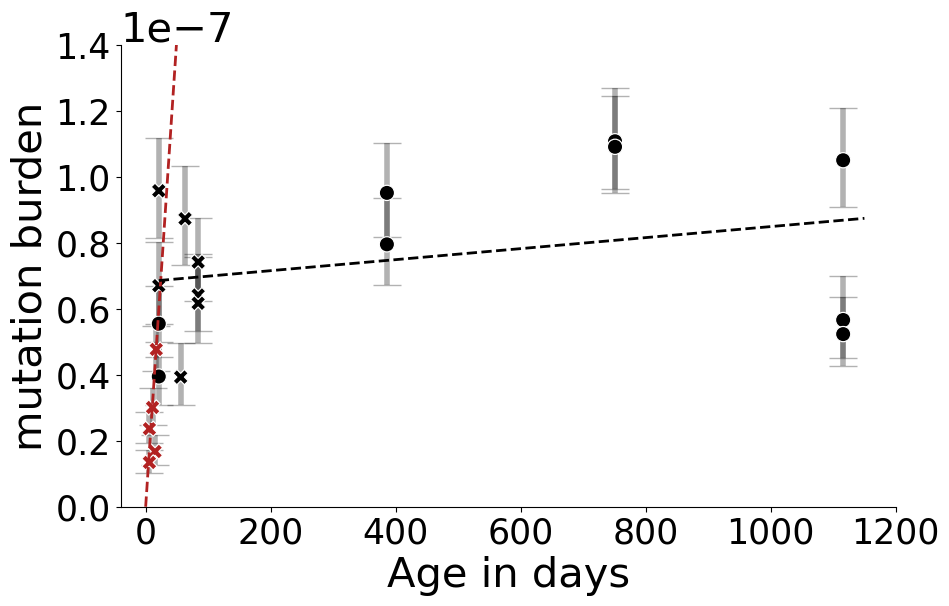

In [622]:
import seaborn as sns
import matplotlib.pyplot as plt


fig, ax = plt.subplots(ncols=1,nrows=1, figsize=(10,6))

#ax.axvspan(0,21, color='mediumaquamarine', alpha=0.5, label='pre-hatching')
#ax.axvline(21, color='lightgrey', linestyle='dotted', label='hatching of workers')


a = 2.843e-09   # slope
b =  0 # assuming intercept at zero
x = np.linspace(0, 50 )
y = a * x + b
ax.plot(x, y, color="firebrick", linestyle="dashed",lw=2, label="juvenile Bee, 1.038e-06/year")

a = 1.67e-11   # slope
b =  6.819e-08  # intercept
x = np.linspace(21, 1150 )
y = a * x + b
ax.plot(x, y, color="black", linestyle="dashed",lw=2, label="adult Bee, 6.0955e-9/year")

# Error bars
ax.errorbar(
    collapsed["agezero"],
    collapsed["burden"],
    yerr=[
        collapsed["burden"] - collapsed["r_low"],
        collapsed["r_high"] - collapsed["burden"]
    ],
    fmt="none",
    ecolor="black",
    capsize=10,
    alpha=0.3,
    linewidth=4,
    zorder=-300
)

# Scatter
sns.scatterplot(
    data=collapsed,
    x="agezero",
    y="burden",
    palette=['black', 'firebrick'],
    hue='juv',
    style='caste',
    ax=ax,
    s=120
)


# Regression line (merged SNV+indel)
#sns.regplot(
#    data=collapsed,
#    x="agezero",
#    y="burden",
#    scatter=False,
#    ci=95,
#    lowess=True,
#    color="black",
#    n_boot=400,
#    line_kws={"linewidth": 3, 'linestyle':'dotted'},
#    ax=ax,
#    label = 'trendline, lowess'
#)




#ax.set_xlim(0,200)
ax.set_xlim(-40,1200)
ax.set_ylim(0,1.4e-7)
ax.set_xlabel("Age in days", size=30)
ax.set_ylabel("mutation burden", size=30)
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)
ax.yaxis.get_offset_text().set_fontsize(30) 
#plt.title("Merged (SNV+Indel) mutation burden vs age in days, all castes, incl. Norwegians")
#plt.legend(loc="center left", bbox_to_anchor=(1, 0.5), fontsize=15)
#plt.legend(loc="lower right", fontsize=20,bbox_to_anchor=(0.90, 0))
ax.legend_.remove()
sns.despine()

plt.savefig('./mutburden_grant_v3.pdf',bbox_inches="tight")
plt.savefig('./mutburden_grant_v3.png',bbox_inches="tight")
plt.savefig('./mutburden_grant_v3.svg',bbox_inches="tight")
plt.show()


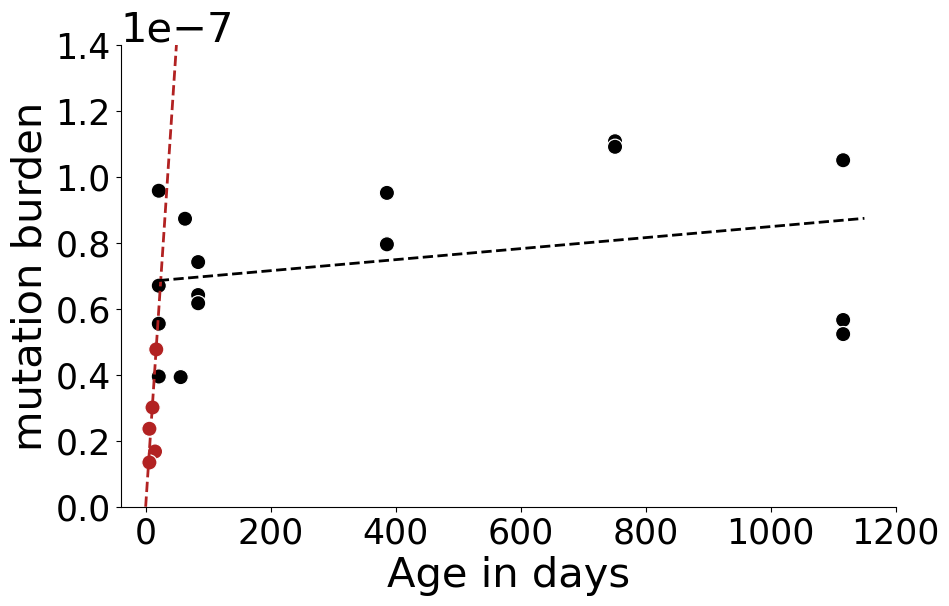

In [625]:
import seaborn as sns
import matplotlib.pyplot as plt


fig, ax = plt.subplots(ncols=1,nrows=1, figsize=(10,6))

#ax.axvspan(0,21, color='mediumaquamarine', alpha=0.5, label='pre-hatching')
#ax.axvline(21, color='lightgrey', linestyle='dotted', label='hatching of workers')


a = 2.843e-09   # slope
b =  0 # assuming intercept at zero
x = np.linspace(0, 50 )
y = a * x + b
ax.plot(x, y, color="firebrick", linestyle="dashed",lw=2, label="juvenile Bee, 1.038e-06/year")

a = 1.67e-11   # slope
b =  6.819e-08  # intercept
x = np.linspace(21, 1150 )
y = a * x + b
ax.plot(x, y, color="black", linestyle="dashed",lw=2, label="adult Bee, 6.0955e-9/year")

# Error bars
#ax.errorbar(
#    collapsed["agezero"],
#    collapsed["burden"],
#    yerr=[
#        collapsed["burden"] - collapsed["r_low"],
#        collapsed["r_high"] - collapsed["burden"]
#    ],
#    fmt="none",
#    ecolor="black",
#    capsize=10,
#    alpha=0.3,
#    linewidth=4,
#    zorder=-300
#)

# Scatter
sns.scatterplot(
    data=collapsed,
    x="agezero",
    y="burden",
    palette=['black', 'firebrick'],
    hue='juv',
    ax=ax,
    s=120
)


# Regression line (merged SNV+indel)
#sns.regplot(
#    data=collapsed,
#    x="agezero",
#    y="burden",
#    scatter=False,
#    ci=95,
#    lowess=True,
#    color="black",
#    n_boot=400,
#    line_kws={"linewidth": 3, 'linestyle':'dotted'},
#    ax=ax,
#    label = 'trendline, lowess'
#)




#ax.set_xlim(0,200)
ax.set_xlim(-40,1200)
ax.set_ylim(0,1.4e-7)
ax.set_xlabel("Age in days", size=30)
ax.set_ylabel("mutation burden", size=30)
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)
ax.yaxis.get_offset_text().set_fontsize(30) 
#plt.title("Merged (SNV+Indel) mutation burden vs age in days, all castes, incl. Norwegians")
#plt.legend(loc="center left", bbox_to_anchor=(1, 0.5), fontsize=15)
#plt.legend(loc="lower right", fontsize=20,bbox_to_anchor=(0.90, 0))
ax.legend_.remove()
sns.despine()

plt.savefig('./mutburden_grant_v4.pdf',bbox_inches="tight")
plt.savefig('./mutburden_grant_v4.png',bbox_inches="tight")
plt.savefig('./mutburden_grant_v4.svg',bbox_inches="tight")
plt.show()


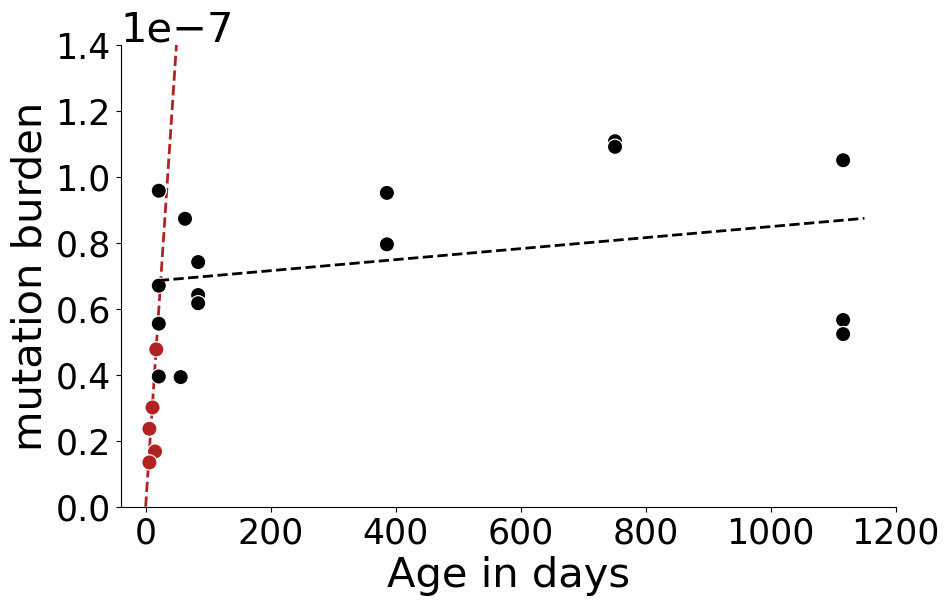

In [628]:
import seaborn as sns
import matplotlib.pyplot as plt


fig, ax = plt.subplots(ncols=1,nrows=1, figsize=(10,6))

#ax.axvspan(0,21, color='mediumaquamarine', alpha=0.5, label='pre-hatching')
#ax.axvline(21, color='lightgrey', linestyle='dotted', label='hatching of workers')


a = 2.843e-09   # slope
b =  0 # assuming intercept at zero
x = np.linspace(0, 50 )
y = a * x + b
ax.plot(x, y, color="firebrick", linestyle="dashed",lw=2, label="juvenile Bee, 1.038e-06/year", zorder=-300)

a = 1.67e-11   # slope
b =  6.819e-08  # intercept
x = np.linspace(21, 1150 )
y = a * x + b
ax.plot(x, y, color="black", linestyle="dashed",lw=2, label="adult Bee, 6.0955e-9/year")

# Error bars
#ax.errorbar(
#    collapsed["agezero"],
#    collapsed["burden"],
#    yerr=[
#        collapsed["burden"] - collapsed["r_low"],
#        collapsed["r_high"] - collapsed["burden"]
#    ],
#    fmt="none",
#    ecolor="black",
#    capsize=10,
#    alpha=0.3,
#    linewidth=4,
#    zorder=-300
#)

# Scatter
sns.scatterplot(
    data=collapsed,
    x="agezero",
    y="burden",
    palette=['black', 'firebrick'],
    hue='juv',
    ax=ax,
    s=120
)


# Regression line (merged SNV+indel)
#sns.regplot(
#    data=collapsed,
#    x="agezero",
#    y="burden",
#    scatter=False,
#    ci=95,
#    lowess=True,
#    color="black",
#    n_boot=400,
#    line_kws={"linewidth": 3, 'linestyle':'dotted'},
#    ax=ax,
#    label = 'trendline, lowess'
#)




#ax.set_xlim(0,200)
ax.set_xlim(-40,1200)
ax.set_ylim(0,1.4e-7)
ax.set_xlabel("Age in days", size=30)
ax.set_ylabel("mutation burden", size=30)
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)
ax.yaxis.get_offset_text().set_fontsize(30) 
#plt.title("Merged (SNV+Indel) mutation burden vs age in days, all castes, incl. Norwegians")
#plt.legend(loc="center left", bbox_to_anchor=(1, 0.5), fontsize=15)
#plt.legend(loc="lower right", fontsize=20,bbox_to_anchor=(0.90, 0))
ax.legend_.remove()
sns.despine()

plt.savefig('./mutburden_grant_v4.pdf',bbox_inches="tight")
plt.savefig('./mutburden_grant_v4.png',bbox_inches="tight")
plt.savefig('./mutburden_grant_v4.svg',bbox_inches="tight")
plt.show()


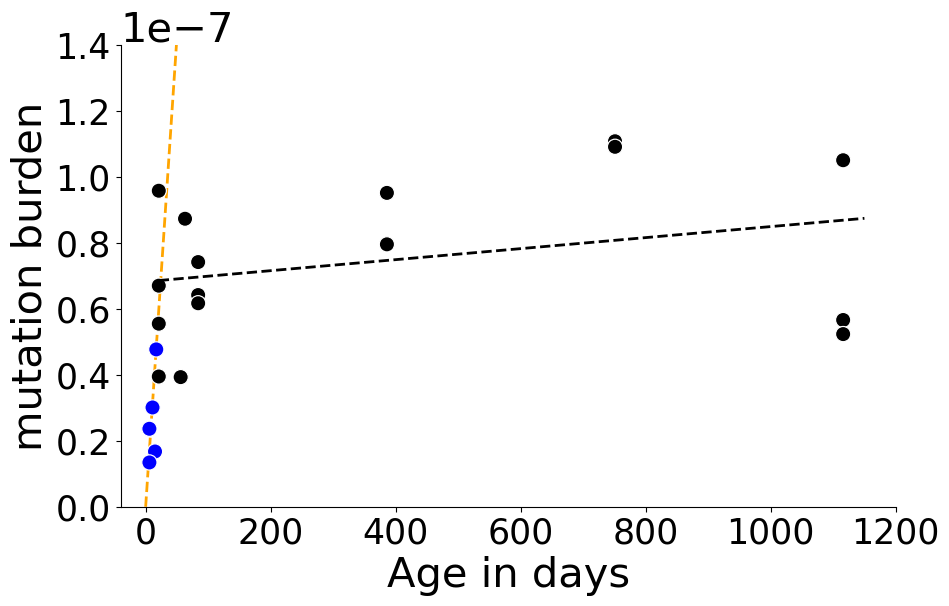

In [629]:
import seaborn as sns
import matplotlib.pyplot as plt


fig, ax = plt.subplots(ncols=1,nrows=1, figsize=(10,6))

#ax.axvspan(0,21, color='mediumaquamarine', alpha=0.5, label='pre-hatching')
#ax.axvline(21, color='lightgrey', linestyle='dotted', label='hatching of workers')


a = 2.843e-09   # slope
b =  0 # assuming intercept at zero
x = np.linspace(0, 50 )
y = a * x + b
ax.plot(x, y, color="orange", linestyle="dashed",lw=2, label="juvenile Bee, 1.038e-06/year", zorder=-300)

a = 1.67e-11   # slope
b =  6.819e-08  # intercept
x = np.linspace(21, 1150 )
y = a * x + b
ax.plot(x, y, color="black", linestyle="dashed",lw=2, label="adult Bee, 6.0955e-9/year")

# Error bars
#ax.errorbar(
#    collapsed["agezero"],
#    collapsed["burden"],
#    yerr=[
#        collapsed["burden"] - collapsed["r_low"],
#        collapsed["r_high"] - collapsed["burden"]
#    ],
#    fmt="none",
#    ecolor="black",
#    capsize=10,
#    alpha=0.3,
#    linewidth=4,
#    zorder=-300
#)

# Scatter
sns.scatterplot(
    data=collapsed,
    x="agezero",
    y="burden",
    palette=['black', 'blue'],
    hue='juv',
    ax=ax,
    s=120
)


# Regression line (merged SNV+indel)
#sns.regplot(
#    data=collapsed,
#    x="agezero",
#    y="burden",
#    scatter=False,
#    ci=95,
#    lowess=True,
#    color="black",
#    n_boot=400,
#    line_kws={"linewidth": 3, 'linestyle':'dotted'},
#    ax=ax,
#    label = 'trendline, lowess'
#)




#ax.set_xlim(0,200)
ax.set_xlim(-40,1200)
ax.set_ylim(0,1.4e-7)
ax.set_xlabel("Age in days", size=30)
ax.set_ylabel("mutation burden", size=30)
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)
ax.yaxis.get_offset_text().set_fontsize(30) 
#plt.title("Merged (SNV+Indel) mutation burden vs age in days, all castes, incl. Norwegians")
#plt.legend(loc="center left", bbox_to_anchor=(1, 0.5), fontsize=15)
#plt.legend(loc="lower right", fontsize=20,bbox_to_anchor=(0.90, 0))
ax.legend_.remove()
sns.despine()

plt.savefig('./mutburden_grant_v5.pdf',bbox_inches="tight")
plt.savefig('./mutburden_grant_v5.png',bbox_inches="tight")
plt.savefig('./mutburden_grant_v5.svg',bbox_inches="tight")
plt.show()


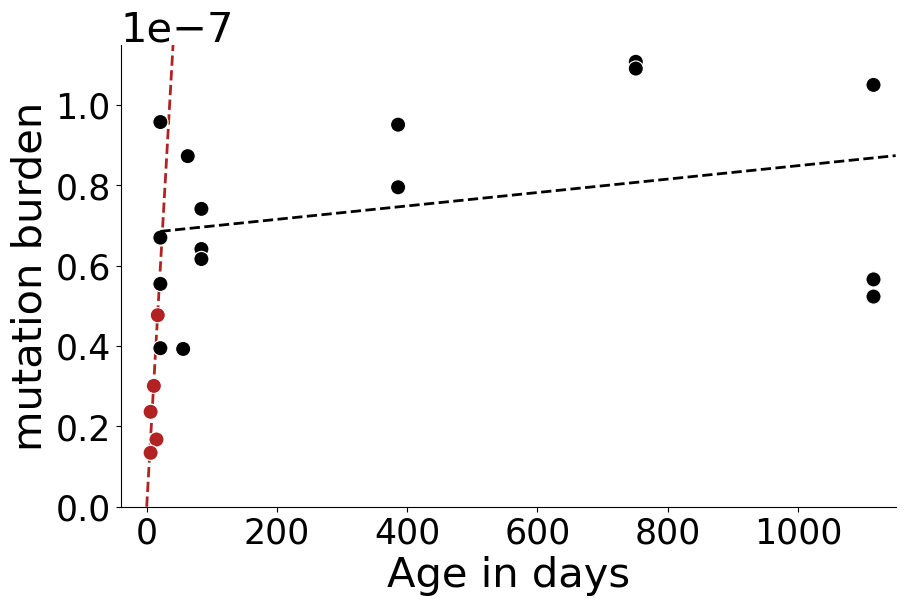

In [635]:
import seaborn as sns
import matplotlib.pyplot as plt


fig, ax = plt.subplots(ncols=1,nrows=1, figsize=(10,6))

#ax.axvspan(0,21, color='mediumaquamarine', alpha=0.5, label='pre-hatching')
#ax.axvline(21, color='lightgrey', linestyle='dotted', label='hatching of workers')


a = 2.843e-09   # slope
b =  0 # assuming intercept at zero
x = np.linspace(0, 50 )
y = a * x + b
ax.plot(x, y, color="firebrick", linestyle="dashed",lw=2, label="juvenile Bee, 1.038e-06/year", zorder=-300)

a = 1.67e-11   # slope
b =  6.819e-08  # intercept
x = np.linspace(21, 1150 )
y = a * x + b
ax.plot(x, y, color="black", linestyle="dashed",lw=2, label="adult Bee, 6.0955e-9/year")

# Error bars
#ax.errorbar(
#    collapsed["agezero"],
#    collapsed["burden"],
#    yerr=[
#        collapsed["burden"] - collapsed["r_low"],
#        collapsed["r_high"] - collapsed["burden"]
#    ],
#    fmt="none",
#    ecolor="black",
#    capsize=10,
#    alpha=0.3,
#    linewidth=4,
#    zorder=-300
#)

# Scatter
sns.scatterplot(
    data=collapsed,
    x="agezero",
    y="burden",
    palette=['black', 'firebrick'],
    hue='juv',
    ax=ax,
    s=120
)


# Regression line (merged SNV+indel)
#sns.regplot(
#    data=collapsed,
#    x="agezero",
#    y="burden",
#    scatter=False,
#    ci=95,
#    lowess=True,
#    color="black",
#    n_boot=400,
#    line_kws={"linewidth": 3, 'linestyle':'dotted'},
#    ax=ax,
#    label = 'trendline, lowess'
#)




#ax.set_xlim(0,200)
ax.set_xlim(-40,1150)
ax.set_ylim(0,1.15e-7)
ax.set_xlabel("Age in days", size=30)
ax.set_ylabel("mutation burden", size=30)
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)
ax.yaxis.get_offset_text().set_fontsize(30) 
#plt.title("Merged (SNV+Indel) mutation burden vs age in days, all castes, incl. Norwegians")
#plt.legend(loc="center left", bbox_to_anchor=(1, 0.5), fontsize=15)
#plt.legend(loc="lower right", fontsize=20,bbox_to_anchor=(0.90, 0))
ax.legend_.remove()
sns.despine()

plt.savefig('./mutburden_grant_v6.pdf',bbox_inches="tight")
plt.savefig('./mutburden_grant_v6.png',bbox_inches="tight")
plt.savefig('./mutburden_grant_v6.svg',bbox_inches="tight")
plt.show()


In [639]:
counts_all.loc[counts_all.variant_type=='snv']['count'].sum()

np.int64(1681)

In [640]:
counts_b4.loc[counts_b4.variant_type=='snv']['count'].sum()

np.int64(348)

In [641]:
counts.loc[counts.variant_type=='snv']['count'].sum()

np.int64(1333)

In [642]:
1333+348

1681

In [644]:
counts_all.to_csv("variant_counts.csv")

In [646]:
collapsed.to_csv("varcounts_joint_b3b4.csv")